Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/praktikum_ml/praktikum05/data/Iris.csv"

In [ ]:
import pandas as pd

df = pd.read_csv(path)
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
print("--- Info Awal ---")
df.info()

print("\n--- Cek Missing Values ---")
print(df.isnull().sum())

print("\n--- Cek Duplikat ---")
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

# Hapus duplikat jika ada
df = df.drop_duplicates()

# Hapus kolom 'Id' karena tidak relevan untuk klasifikasi
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

print("\n--- Data Setelah Cleaning (5 Baris Pertama) ---")
print(df.head())

--- Info Awal ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- Cek Missing Values ---
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

--- Cek Duplikat ---
Jumlah data duplikat: 3

--- Data Setelah Cleaning (5 Baris Pertama) ---
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-se

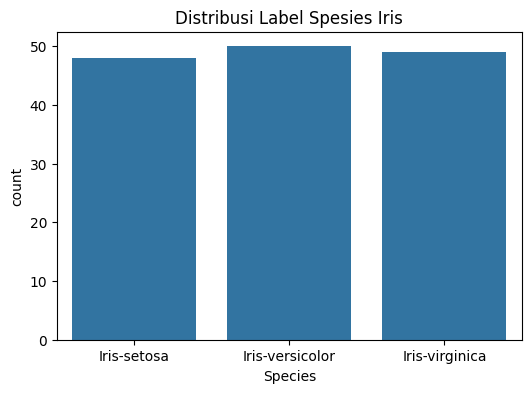

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Species', data=df)
plt.title('Distribusi Label Spesies Iris')
plt.show()

In [ ]:
# Buat LabelEncoder
label_encoder = LabelEncoder()

# Ubah target 'Species' menjadi angka
# Kita buat kolom baru 'Species_encoded' agar kolom asli tetap ada
df['Species_encoded'] = label_encoder.fit_transform(df['Species'])

# Simpan nama asli spesies untuk laporan dan visualisasi
species_names = label_encoder.classes_

print("--- Nama Kelas (Mapping) ---")
for i, name in enumerate(species_names):
    print(f"{i}: {name}")

print("\n--- Data Setelah Encoding (5 Baris Pertama) ---")
print(df.head())

--- Nama Kelas (Mapping) ---
0: Iris-setosa
1: Iris-versicolor
2: Iris-virginica

--- Data Setelah Encoding (5 Baris Pertama) ---
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0            5.1           3.5            1.4           0.2  Iris-setosa   
1            4.9           3.0            1.4           0.2  Iris-setosa   
2            4.7           3.2            1.3           0.2  Iris-setosa   
3            4.6           3.1            1.5           0.2  Iris-setosa   
4            5.0           3.6            1.4           0.2  Iris-setosa   

   Species_encoded  
0                0  
1                0  
2                0  
3                0  
4                0  


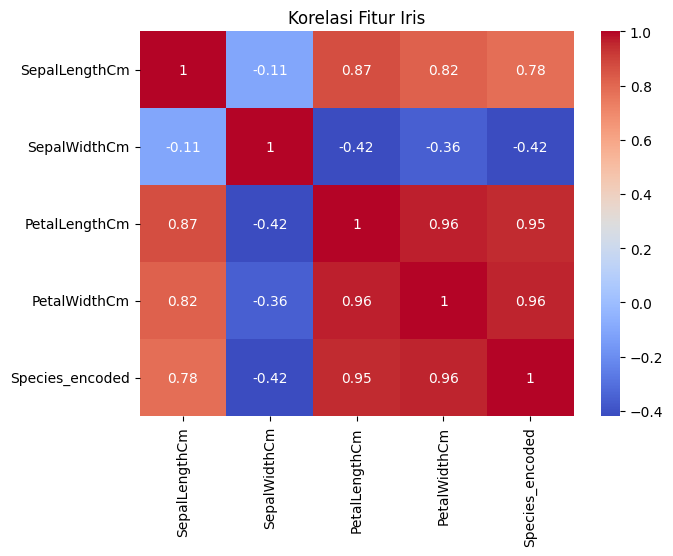

In [ ]:
plt.figure(figsize=(7,5))
# Kita drop kolom 'Species' (teks) sebelum menghitung korelasi
sns.heatmap(df.drop('Species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Iris')
plt.show()

In [ ]:
# Memilih fitur
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[feature_cols]

# Memilih target (kolom yang sudah di-encode)
y = df['Species_encoded']

print("--- Fitur (X) ---")
print(X.head())
print("\n--- Target (y) ---")
print(y.head())

--- Fitur (X) ---
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

--- Target (y) ---
0    0
1    0
2    0
3    0
4    0
Name: Species_encoded, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% untuk data uji
    random_state=42,  # Agar hasil konsisten
    stratify=y        # Menjaga proporsi kelas
)

print(f"Ukuran data training: {len(X_train)}")
print(f"Ukuran data testing: {len(X_test)}")

Ukuran data training: 117
Ukuran data testing: 30


In [ ]:
# Membangun model
dt_model_awal = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

# Melatih model
dt_model_awal.fit(X_train, y_train)

print("--- Model Awal (max_depth=4) Selesai Dilatih ---")

--- Model Awal (max_depth=4) Selesai Dilatih ---


In [ ]:
# Evaluasi model awal
y_pred_awal = dt_model_awal.predict(X_test)

print("--- Evaluasi Model Awal (max_depth=4) ---")
print("Akurasi:", round(accuracy_score(y_test, y_pred_awal) * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_awal))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred_awal, target_names=species_names
))

--- Evaluasi Model Awal (max_depth=4) ---
Akurasi: 93.33 %

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



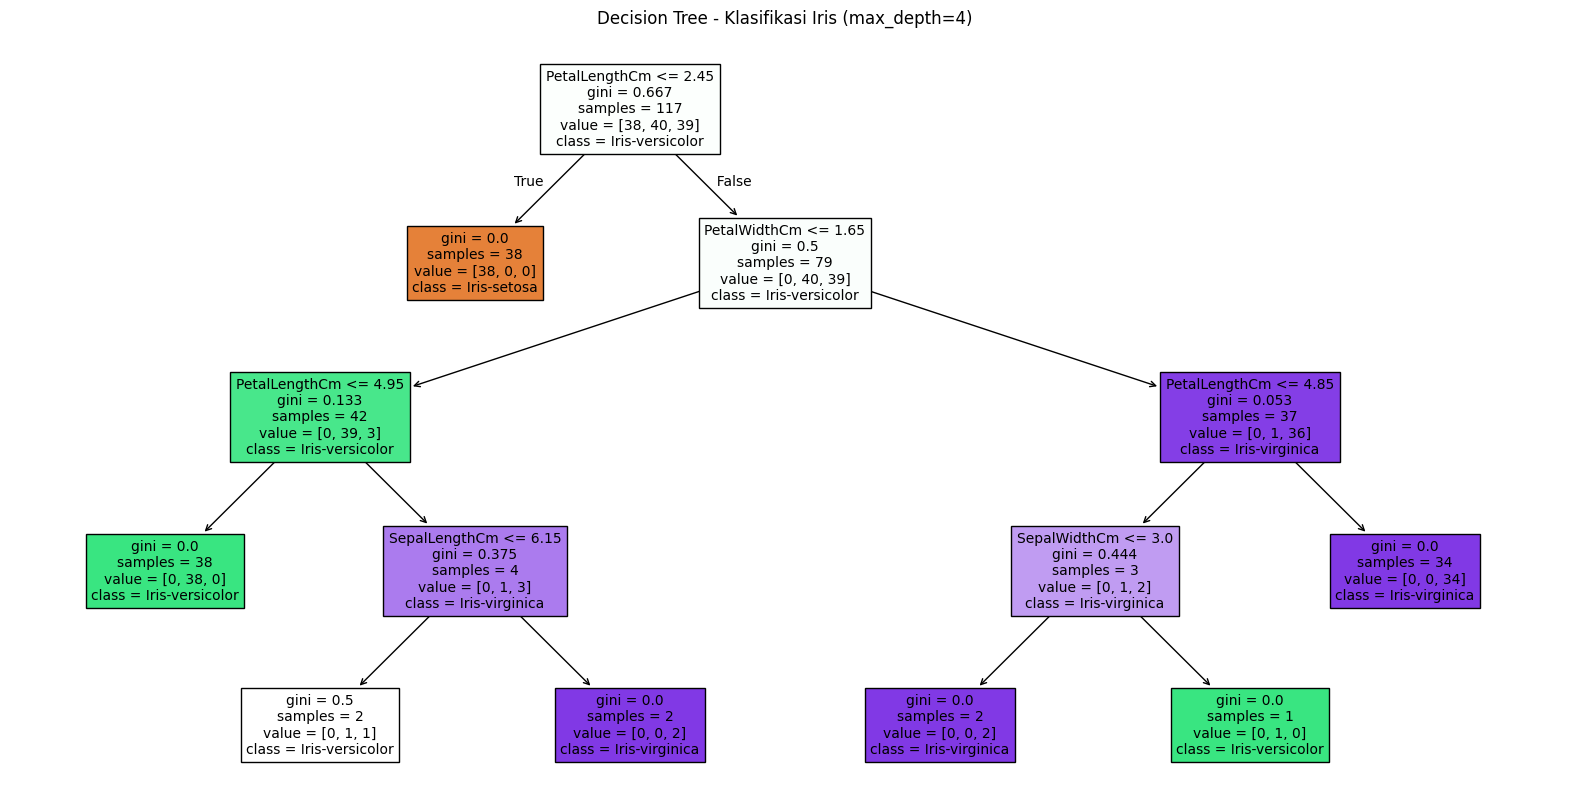

In [ ]:
# Visualisasi model
plt.figure(figsize=(20,10)) # Ukuran bisa disesuaikan
plot_tree(
    dt_model_awal,
    feature_names=feature_cols,
    class_names=species_names,
    filled=True,
    fontsize=10
)
plt.title('Decision Tree - Klasifikasi Iris (max_depth=4)')
plt.show()

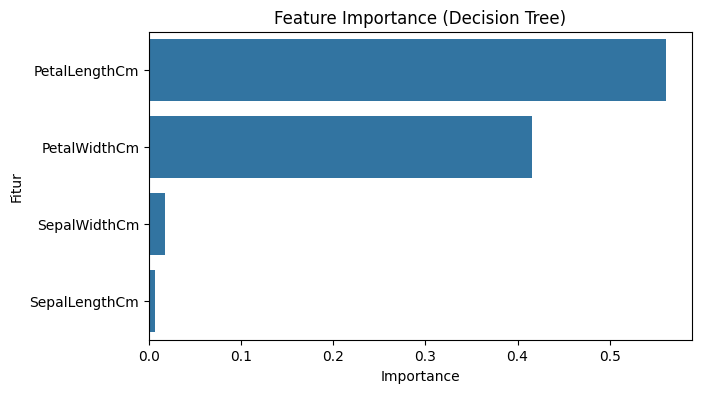


--- Nilai Feature Importance ---
PetalLengthCm    0.560816
PetalWidthCm     0.415369
SepalWidthCm     0.017320
SepalLengthCm    0.006495
dtype: float64


In [ ]:
imp = pd.Series(dt_model_awal.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=imp, y=imp.index)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.show()

print("\n--- Nilai Feature Importance ---")
print(imp)

In [ ]:
scores = {}
for d in range(2, 9): # Mencoba kedalaman 2 s/d 8
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    scores[d] = accuracy_score(y_test, m.predict(X_test))

print("--- Hasil Tuning max_depth (Akurasi) ---")
print(scores)

best_d = max(scores, key=scores.get)
print(f"\nBest max_depth: {best_d} | Akurasi: {round(scores[best_d] * 100, 2)} %")

--- Hasil Tuning max_depth (Akurasi) ---
{2: 0.9333333333333333, 3: 0.9666666666666667, 4: 0.9333333333333333, 5: 0.9333333333333333, 6: 0.9333333333333333, 7: 0.9333333333333333, 8: 0.9333333333333333}

Best max_depth: 3 | Akurasi: 96.67 %
